In [1]:
library(vcd)
library(lsr)
library(dplyr)
library(ggplot2)
library(tidyr)
library(stringr)
library(tidyverse)

Loading required package: grid


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(readxl)
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:lubridate’:

    second, second<-


The

In [ ]:
meta<-read.delim("../1_DATA/sample_meta_passQC.tsv")
samples<-read.delim("../1_DATA/metrics_passQC.tsv")
# %>%filter(ORIGIN=="MCC")

# Inner join: keep only overlapping Record_IDs
# meta_overlap <- merge(meta, samples, by = "sample_id", all = FALSE)
meta_overlap2<-read.delim("../MCC_clinical_data.tsv")
counts<-read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
# meta_overlap2<- read_excel("/workdir/gfa32/hsct_new/PAPER2_cfrna/data/Baseline_data_clean.xlsx")

exempt <- merge(meta, meta_overlap2, by = "Record_ID", all = FALSE)

converting counts to integer mode

using ntop=500 top features by variance



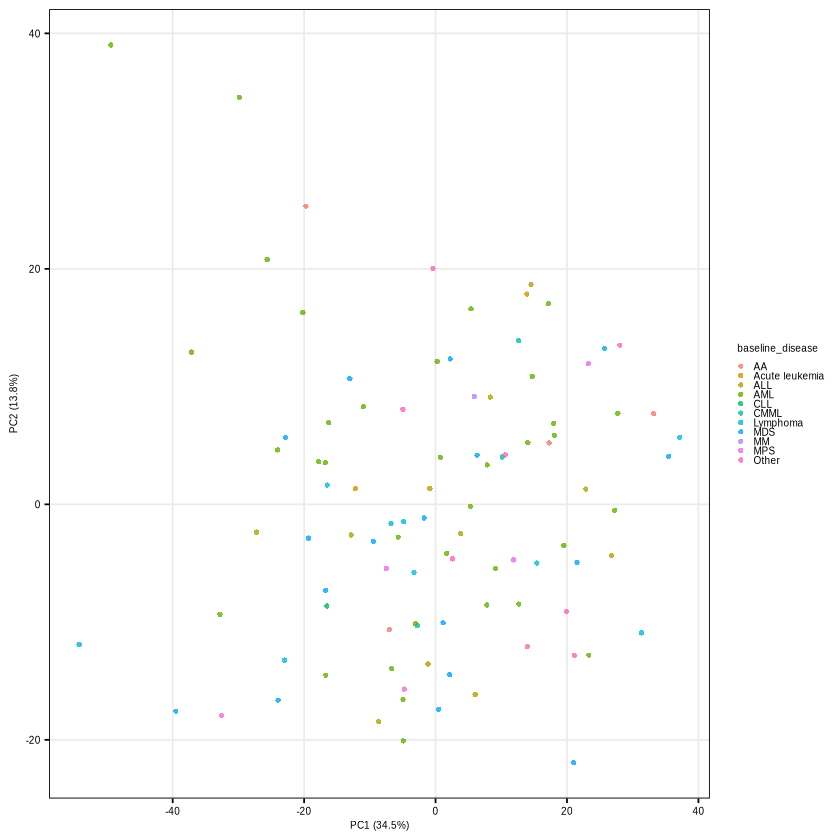

In [ ]:
sample_ids <- intersect(colnames(cnt_mat), exempt$sample_id)
cnt_sub    <- cnt_mat[, sample_ids, drop=FALSE]

# deduplicate by sample_id before building colData
meta_pca <- exempt %>%
    filter(sample_id %in% sample_ids) %>%
    distinct(Record_ID, .keep_all = TRUE) %>%          
    arrange(match(sample_id, colnames(cnt_sub))) %>%   
    mutate(ppx = as.factor(ppx))
rownames(meta_pca) <- meta_pca$sample_id

cnt_int <- round(cnt_sub[, meta_pca$sample_id])       
cnt_int <- cnt_int[rowSums(cnt_int) > 0, ]

dds <- DESeqDataSetFromMatrix(
    countData = cnt_int,
    colData   = meta_pca,
    design    = ~ 1
)

vst_obj  <- vst(dds, blind = TRUE)
pca_data <- plotPCA(vst_obj, intgroup = "ppx", returnData = TRUE)
pct_var  <- round(100 * attr(pca_data, "percentVar"), 1)

pca_plt <- pca_data %>%
    ggplot(aes(x=PC1, y=PC2, color=group)) +
    geom_point(size=1.5, alpha=0.8, stroke=NA) +
    labs(x=sprintf("PC1 (%s%%)", pct_var[1]),
         y=sprintf("PC2 (%s%%)", pct_var[2]),
         color="ppx") +
    theme(panel.grid.minor  = element_blank(),
          legend.position   = "right",
          legend.title      = element_text(size=6),
          legend.text       = element_text(size=6),
          legend.key.size   = unit(0.3, "lines"),
          legend.spacing.y  = unit(0, "pt"))

pca_plt
WIDTH = 3.1
HEIGHT = 1.5
ggsave("/PCA_baseline_immunosupression.pdf", width = WIDTH, height = HEIGHT)